## Table of Contents

1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Feature Engineering](#Feature-Engineering)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
1. [Model Development](#Model-Development)
    1. [Training Set Evaluation](#Training-Set-Evaluation)
    1. [Dev Set Evaluation](#Dev-Set-Evaluation)
    1. [Cross-Validation Evaluation](#Cross-Validation-Evaluation)
    1. [Training Holdout Set Evaluation](#Training-Holdout-Set-Evaluation)
    1. [Evaluation Summary](#Evaluation-Summary)
1. [Submission File Generation](#Submission-File-Generation)

## Introduction

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, Kaggle asked us to build a predictive model that answers the question: **“What sorts of people were more likely to survive?”** using passenger data (e.g. name, age, gender, socio-economic class, etc).

In [32]:
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp

import mlflow
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Inferred schema contains integer column.*",
    module="mlflow\\.types\\.utils"
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
import shap

## Data Understanding

Kaggle provided passenger data split into two files:
* "Test set" (<a href="./input/test.csv">test.csv</a>)
    * 418 rows, 11 features (no `Survived` col)
    * Loaded into `X_test`
* "Training set" (<a href="./input/train.csv">train.csv</a>)
    * 891 rows, 12 features
    * Loaded into `X_train`

The feature distributions between `X_train` and `X_test` will be explored to confirm Training set is representative of Test set prior to model training.  
* If distribution differences are found, `X_train` will be adjusted to become representative of `X_test` prior to model training.

Once `X_train` is confirmed representative of `X_test` data, `X_train` will be split into the following sets:
* `X_train_holdout, y_train_holdout` (20%): 
    * Model will never be trained on this data.  
    * Used to measure final generalization error before generating submission file using `X_test`.
* `X_train, y_train` (60%): 
    * Used to train models (`model.fit(X_train, y_train)`).
    * Used to evaluate model bias (`model.predict(X_train)`)
* `X_dev, y_dev` (20%): 
    * Initially held out from model training to evaluate model variance (`model.predict(X_dev)`)
    * Majority of feature engineering and model selection w/ hyperparameter tuning performed at this stage.

After bias/variance tradeoff is optimized between `X_train` and `X_dev` evaluations, the following actions are taken:
* `X_train, y_train` and `X_dev, y_dev` sets will be combined into `X_train_full` 
* Cross-validation (`k=5`) will be conducted on `X_train_full` to evaluate the model's ability to generalize to various validation fold distributions.

After model features and hyperparameters have been optimized using `X_train`, `X_dev`, and `X_train_full` experimentation, the model is used to predict `X_train_holdout` labels to confirm final generalization error rate is acceptable.

In [2]:
training_set_df = pd.read_csv('./input/train.csv')
target = 'Survived'
X_train = training_set_df.drop(columns=target)
y_train = training_set_df[target]

X_test = pd.read_csv('./input/test.csv')

In [3]:
X_train.shape, X_test.shape

((891, 11), (418, 11))

### Data Dictionary

| Variable | Definition | Key, Example |
| -------- | ---------- | --- |
| **Survived** | Survival | 0 = No, 1 = Yes |
| **PassengerId** | Integer index of passenger | 0,1,2,3,... |
| **Name** | Name of passenger including title | Braund, Mr. Owen Harris |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Sex** | Sex | female, male |
| **Age** | Age in years | 0.15, 2, 15 |
| **SibSp** | # of siblings / spouses aboard the Titanic | 0,1,2,3,.. |
| **Parch** | # of parents / children aboard the Titanic | 0,1,2,3,.. |
| **Ticket** | Ticket number, some with prefixes, **shared among groups** | SW/PP 751 |
| **Fare** | Passenger fare, **shared among groups**	 | 7.91, 14.4542, 512.3292 |
| **Cabin** | Cabin number(s) listed on ticket, prefixed with deck letter, **shared among groups**	 | A20, "B57 B59 B63 B66"	 |
| **Embarked** | Port of Embarkation | C = Cherbourg (France), Q = Queenstown (Ireland), S = Southampton (England) |

#### Variable Notes

**pclass:** A proxy for socio-economic status (SES)
* 1st = Upper
* 2nd = Middle
* 3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
* Sibling = brother, sister, stepbrother, stepsister
* Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
* Parent = mother, father
* Child = daughter, son, stepdaughter, stepson
* Some children travelled only with a nanny, therefore parch=0 for them.

### Descriptive Statistics

In [4]:
X_train.describe(include='number')

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Initial insights:
* **PassengerId:** column is most likely a sequential integer index from 1 to 891
* **Survived:** Mean survival rate for this data set is 38.4%
* **Pclass:** Top 25% of passengers were in 1st and 2nd Class, remainder in 3rd class
* **Age:** Youngest child was less than 6 months old, oldest is 80 years old.  Median age 28 yrs, 75th pecentile 38 yrs.  177 values missing
* **SibSp / Parch**:  At least 50% of passengers traveled alone, 75% passengers had at most 1 sibling or spouse.  Max family size is 8
* **Fare:** Fares ranged from 0.00 (potentially crew?) to 512.32.  Median fare 14.45, 75th percentile 31.00 - highest fares likely correlates with upper class

In [5]:
X_train.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


Initial insights:
* **Name:** Contains surname and title info, probable tokens for splitting
* **Sex:** Majority of passengers were male
* **Ticket:** Contains number; some contain prefixes with potentially useful info. 210 passengers shared the same ticket number, indicating traveling together (may be family and/or household staff)
* **Cabin:** Contains room number and deck letter prefix.  Some cabin strings contain multiple cabin numbers, may also signal family or household staff relationships.  687 values missing
* **Embarked:** Majority of passengers embarked from Southampton, England (644).  2 values missing

### Row Samples

In [6]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Types

In [7]:
X_train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Missing Values Summary

In [8]:
print(X_train.isnull().sum().loc[lambda x: x > 0])
print()
print(X_test.isnull().sum().loc[lambda x: x > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64

Age       86
Fare       1
Cabin    327
dtype: int64


### Sample Visual Inspection

Visual inspection shows variaion in **ticket prefixes**, **cabin numbers (e.g. multiple numbers)** and **name tokens (e.g. title, multiple names)**.

In [9]:
# Run multiple times to see different samples
X_train.sample(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
157,158,3,"Corn, Mr. Harry",male,30.0,0,0,SOTON/OQ 392090,8.0500,NaN,S
720,721,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
329,330,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C
417,418,2,"Silven, Miss. Lyyli Karoliina",female,18.0,0,2,250652,13.0000,NaN,S
484,485,1,"Bishop, Mr. Dickinson H",male,25.0,1,0,11967,91.0792,B49,C
876,877,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
885,886,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
495,496,3,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C
714,715,2,"Greenberg, Mr. Samuel",male,52.0,0,0,250647,13.0000,NaN,S
856,857,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


In [10]:
X_test.sample(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S
220,1112,2,"Duran y More, Miss. Florentina",female,30.0,1,0,SC/PARIS 2148,13.8583,NaN,C
171,1063,3,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C
129,1021,3,"Petersen, Mr. Marius",male,24.0,0,0,342441,8.0500,NaN,S
284,1176,3,"Rosblom, Miss. Salli Helena",female,2.0,1,1,370129,20.2125,NaN,S
207,1099,2,"Collett, Mr. Sidney C Stuart",male,24.0,0,0,28034,10.5000,NaN,S
72,964,3,"Nieminen, Miss. Manta Josefina",female,29.0,0,0,3101297,7.9250,NaN,S
78,970,2,"Aldworth, Mr. Charles Augustus",male,30.0,0,0,248744,13.0000,NaN,S
126,1018,3,"Brobeck, Mr. Karl Rudolf",male,22.0,0,0,350045,7.7958,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [11]:
# Split X_train into X_train_holdout, X_train, and X_dev sets (20/60/20 split)
def split_data(X, y, holdout_size=0.2, dev_size=0.2, random_state=42):
    """
    Splits the dataset into training, holdout, and development sets.
    
    Parameters:
    - X: Features DataFrame
    - y: Target Series
    - holdout_size: Proportion of data to be used as holdout set
    - dev_size: Proportion of training data to be used as development set
    - random_state: Random seed for reproducibility
    
    Returns:
    - X_train: Training features
    - X_train_holdout: Holdout features
    - y_train: Training target
    - y_train_holdout: Holdout target
    """
    X_train, X_train_holdout, y_train, y_train_holdout = train_test_split(X, y, test_size=holdout_size, stratify=y, random_state=random_state)
    X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, test_size=dev_size / (1 - holdout_size), stratify=y_train, random_state=random_state)

    return X_train, X_train_holdout, X_dev, y_train, y_train_holdout, y_dev


X_train, X_train_holdout, X_dev, y_train, y_train_holdout, y_dev = split_data(X_train, y_train)
X_train.shape, X_train_holdout.shape, X_dev.shape

((534, 11), (179, 11), (178, 11))

## Exploratory Data Analysis

In [12]:
def remove_duplicates_and_trim(X_df, features, y_df=None, target='Survived'):
    """ 
    Remove duplicate rows based on specified features and according to the following rules:
        1. If all samples of a given feature combination have the same target, 
            the duplicate feature/target rows are removed.
        2. If the target values differ, the majority class is identified, the first row of the feature
           combination is kept with its target set to the majority class.
    
    Parameters:
    - X_df: DataFrame containing only the specified features
    - features: List of feature names to check for duplicates
    - y_df: Series containing Survived target values (optional)

    Returns:
    - X_df: DataFrame with duplicates removed
    - y_df: Series with corresponding target values, if provided
    """
    if y_df is not None:
        combined_df = pd.concat([X_df[features], y_df], axis=1)
    else:
        empty_target = pd.Series(np.nan, index=X_df.index, name=target)
        combined_df = pd.concat([X_df[features], empty_target], axis=1)

    # Identify duplicates
    duplicates = combined_df.duplicated(subset=features, keep=False)
    if not duplicates.any():
        print("No duplicates found based on the specified features.")
        return X_df, y_df
    
    # Group by the features and aggregate the target values
    resolved_df = combined_df.groupby(features)[target].agg(
        lambda x: x.mode().iloc[0]  # Take majority class
    ).reset_index()

    print('Before Deduplication and Trim: %s, %s' % (X_df.shape, y_df.shape if y_df is not None else 'N/A'))
    print('After Deduplication and Trim: %s, %s' % (resolved_df[features].shape, resolved_df[target].shape))

    return resolved_df[features], resolved_df[target]

In [13]:
def numeric_features(X_df, features):
    """
    Returns a list of numeric features from the DataFrame.
    
    Parameters:
    - X_df: DataFrame containing the features
    - features: List of feature names to check
    
    Returns:
    - List of numeric feature names
    """
    return [feature for feature in features if pd.api.types.is_numeric_dtype(X_df[feature])]

In [14]:
target = 'Survived'
selected_features = [feature for feature in X_train.columns.tolist() if feature not in ['Name', 'Ticket', 'PassengerId']]
print(f"Selected features: {selected_features}")

Selected features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']


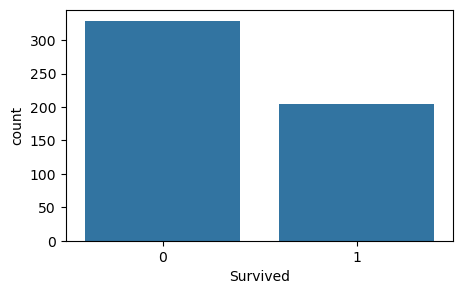

Global Survival Rate: 0.3839
Baseline Accuracy (if predicting majority class): 0.6161


In [15]:
y_df = pd.DataFrame(y_train).reset_index(drop=True)

plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=y_df)
plt.show()

global_survival_rate = y_df['Survived'].mean()
print(f"Global Survival Rate: {global_survival_rate:.4f}")
print(f"Baseline Accuracy (if predicting majority class): {max(global_survival_rate, 1 - global_survival_rate):.4f}") 

## Feature Engineering

In [16]:
def engineer_features(df):

    # Create Sex_Encoded feature
    df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

    # Create Deck feature from CabinCabin
    df['Deck'] = df['Cabin'].str[0]

    # Fill missing Deck values with 'U' for Unknown
    df['Deck'] = df['Deck'].fillna('U')

    # Create Title feature from Name
    def extract_title(name):
        title = name.split(',')[1].split('.')[0].strip()
        return title
    df['Title'] = df['Name'].apply(extract_title)

    # Create Surname feature from Name
    def extract_surname(name):
        surname = name.split(',')[0].strip()
        return surname
    df['Surname'] = df['Name'].apply(extract_surname)

    # Create Ticket Prefix and Number features from Ticket
    def extract_ticket_info(ticket):
        if pd.isnull(ticket):
            return None, None
        parts = ticket.split()
        prefix = parts[0] if len(parts) > 1 else ''
        number = parts[-1] if len(parts) > 1 else parts[0]
        return prefix, number
    df[['Ticket_Prefix', 'Ticket_Number']] = df['Ticket'].apply(lambda x: pd.Series(extract_ticket_info(x)))

    # Print non-numeric Ticket Numbers in training data with counts
    non_numeric_ticket_numbers = df[~df['Ticket_Number'].str.isnumeric()]['Ticket_Number'].value_counts()
    print("Non-numeric Ticket Numbers in training data:")
    print(non_numeric_ticket_numbers)

    # Set 4 'LINE' Ticket Numbers to -1
    df.loc[df['Ticket_Number'].isin(['LINE']), 'Ticket_Number'] = -1

    # Create Ticket Frequency feature from Ticket Number on training data only
    #ticket_freq_train = X_train['Ticket_Number'].value_counts().to_dict()
    #df['Ticket_Frequency'] = df['Ticket_Number'].map(ticket_freq_train)

    # Calculate Fare per Person
    #df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']
    #df['Fare_Per_Person_Scaled'] = (df['Fare_Per_Person'] - df['Fare_Per_Person'].mean()) / df['Fare_Per_Person'].std()

    # def bin_ticket_frequency(freq):
    #     if freq < 4:
    #         return freq
    #     else:
    #         return 4
    # df['Ticket_Frequency'] = df['Ticket_Frequency'].apply(bin_ticket_frequency)

    # Create Family Size feature
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    def bin_family_size(size):
        if size < 4:
            return size
        else:
            return 4
    df['Family_Size'] = df['Family_Size'].apply(bin_family_size)

    # Create Is_Alone feature
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # Create Cabin_Count feature from Cabin
    df['Cabin_Count'] = df['Cabin'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
    def bin_cabin_count(cabin_count):
        if cabin_count < 2:
            return cabin_count
        else:
            return 2
    df['Cabin_Count'] = df['Cabin_Count'].apply(bin_cabin_count)

    # Create Cabin Number feature
    # If feature contains multiple numbers, use the first one
    # If feature contains no numbers, set to NaN    
    df['Cabin_Number'] = df['Cabin'].str.extract(r'[A-Z](\d+)').astype('Int64')
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)


    # Create Port or Starboard feature based on Cabin Number
    def cabin_side(cabin_number):
        if pd.isnull(cabin_number):
            return 'Unknown'
        return 'Starboard' if cabin_number % 2 == 0 else 'Port'
    df['Cabin_Side'] = df['Cabin_Number'].apply(cabin_side)

    # Create Cabin_Missing feature
    df['Cabin_Missing'] = df['Cabin'].isnull().astype(int)

    # Fill missing Cabin_Number values with 0
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)

    # Fill missing Embarked with the most common value for the same Pclass
    def fill_missing_embarked(row):
        if pd.notna(row['Embarked']):
            return row['Embarked']
        # If Embarked is missing, fill with the most common value for the same Pclass
        return df[df['Pclass'] == row['Pclass']]['Embarked'].mode().iloc[0] if not df[df['Pclass'] == row['Pclass']]['Embarked'].mode().empty else 'S'
    df['Embarked'] = df.apply(fill_missing_embarked, axis=1)

    # Create Age_Missing feature
    df['Age_Missing'] = df['Age'].isnull().astype(int)

    # Imput missing Age values using median of Pclass/Title gr
    def impute_age(df):

        # First attempt to impute by Pclass X Title
        pclass_title_age_median_map = df.groupby(['Pclass', 'Title'])['Age'].median()
        def impute_age_by_pclass_title(row):
            if pd.notna(row['Age']):
                return row['Age']
            return pclass_title_age_median_map.loc[row['Pclass'], row['Title']]
        df['Age'] = df.apply(impute_age_by_pclass_title, axis=1)

        # In the scenario where all ages for a given title are missing, impute with median age for Sex
        sex_age_median_map = df.groupby(['Sex'])['Age'].median()
        def impute_age_by_sex(row):
            if pd.notna(row['Age']):
                return row['Age']
            return sex_age_median_map.loc[row['Sex']]
        df['Age'] = df.apply(impute_age_by_sex, axis=1)
    impute_age(df)

    df['Is_Child'] = (df['Age'] < 10).astype(int)

    return df


In [17]:
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    2
Name: count, dtype: int64
Non-numeric Ticket Numbers in training data:
Series([], Name: count, dtype: int64)


In [27]:
target = 'Survived'
high_cardinality_features = ['Name', 'Ticket', 'Cabin', 'PassengerId', 'Ticket_Number']
meaningful_features = [feature for feature in X_train.columns.tolist() if feature not in high_cardinality_features]
print(f"Meaningful features: {meaningful_features}")

Meaningful features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Sex_Encoded', 'Deck', 'Title', 'Surname', 'Ticket_Prefix', 'Family_Size', 'Is_Alone', 'Cabin_Count', 'Cabin_Number', 'Cabin_Side', 'Cabin_Missing', 'Age_Missing', 'Is_Child']


In [19]:
# Trim training data to remove duplicates and select majority class for conflicting rows
X_train, y_train = remove_duplicates_and_trim(X_train, meaningful_features, y_train)

Before Deduplication and Trim: (534, 25), (534,)
After Deduplication and Trim: (533, 21), (533,)


In [20]:
vif_minimized_features = numeric_features(X_train, [
    'Pclass', 'Sex', 'Age',  
    'Embarked', 'Sex_Encoded', 'Deck', 'Title', 'Surname', 
    'Ticket_Prefix', 'Ticket_Number', 
    'Cabin_Count', 'Cabin_Side', 
     'Is_Child',
    #'Fare', 'Age_Missing', 'Family_Size', 'Cabin_Number',
    #'Cabin_Missing',
    #'Is_Alone',
    #'SibSp', 
    #'Parch',
]) 

# Check Variance Inflation Factor (VIF) of each feature
X_vif = add_constant(X_train[vif_minimized_features])
X_vif = X_vif.astype(float)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

       Feature        VIF
0        const  39.827011
1       Pclass   2.065212
2          Age   1.691827
3  Sex_Encoded   1.051143
4  Cabin_Count   1.817891
5     Is_Child   1.412051


## Training x Test Set Distribution Comparison

In [33]:
def statistical_distribution_tests(X_train, X_test, meaningful_features):
    """
    Perform statistical tests to detect distribution differences.
    """
    print("="*60)
    print("STATISTICAL DISTRIBUTION TESTS")
    print("="*60)
    
    significant_diffs = []
    
    for feature in meaningful_features:
        print(f"\n--- {feature} ---")
        
        train_data = X_train[feature].dropna()
        test_data = X_test[feature].dropna()
        
        if pd.api.types.is_numeric_dtype(X_train[feature]):
            # Kolmogorov-Smirnov test for numeric features
            ks_stat, ks_p = ks_2samp(train_data, test_data)
            print(f"KS Test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")
            
            if ks_p < 0.05:
                significant_diffs.append((feature, 'KS', ks_p))
                print(f"  ⚠️  SIGNIFICANT DIFFERENCE (p < 0.05)")
            
            # Compare means and std
            train_mean, train_std = train_data.mean(), train_data.std()
            test_mean, test_std = test_data.mean(), test_data.std()
            print(f"Train: mean={train_mean:.3f}, std={train_std:.3f}")
            print(f"Test:  mean={test_mean:.3f}, std={test_std:.3f}")
            print(f"Mean diff: {abs(train_mean - test_mean):.3f}")
            
        else:
            # Chi-square test for categorical features
            train_counts = train_data.value_counts()
            test_counts = test_data.value_counts()
            
            # Align categories
            all_categories = set(train_counts.index) | set(test_counts.index)
            train_aligned = [train_counts.get(cat, 0) for cat in all_categories]
            test_aligned = [test_counts.get(cat, 0) for cat in all_categories]
            
            if len(all_categories) > 1 and sum(train_aligned) > 0 and sum(test_aligned) > 0:
                chi2_stat, chi2_p, _, _ = chi2_contingency([train_aligned, test_aligned])
                print(f"Chi-square test: statistic={chi2_stat:.4f}, p-value={chi2_p:.4f}")
                
                if chi2_p < 0.05:
                    significant_diffs.append((feature, 'Chi2', chi2_p))
                    print(f"  ⚠️  SIGNIFICANT DIFFERENCE (p < 0.05)")
            
            print(f"Train proportions: {dict(train_data.value_counts(normalize=True).round(3))}")
            print(f"Test proportions:  {dict(test_data.value_counts(normalize=True).round(3))}")
    
    print(f"\n{'='*60}")
    print(f"SUMMARY: {len(significant_diffs)} features with significant differences:")
    for feature, test, p_val in significant_diffs:
        print(f"  • {feature} ({test}): p = {p_val:.4f}")
    
    return significant_diffs

# Run the tests
significant_diffs = statistical_distribution_tests(X_train, X_test, meaningful_features)

STATISTICAL DISTRIBUTION TESTS

--- Pclass ---
KS Test: statistic=0.0244, p-value=0.9982
Train: mean=2.306, std=0.833
Test:  mean=2.266, std=0.842
Mean diff: 0.040

--- Sex ---
Chi-square test: statistic=0.0486, p-value=0.8256
Train proportions: {'male': 0.645, 'female': 0.355}
Test proportions:  {'male': 0.636, 'female': 0.364}

--- Age ---
KS Test: statistic=0.1460, p-value=0.0001
  ⚠️  SIGNIFICANT DIFFERENCE (p < 0.05)
Train: mean=29.827, std=13.581
Test:  mean=29.403, std=13.169
Mean diff: 0.424

--- SibSp ---
KS Test: statistic=0.0209, p-value=0.9999
Train: mean=0.482, std=1.027
Test:  mean=0.447, std=0.897
Mean diff: 0.035

--- Parch ---
KS Test: statistic=0.0171, p-value=1.0000
Train: mean=0.402, std=0.856
Test:  mean=0.392, std=0.981
Mean diff: 0.009

--- Fare ---
KS Test: statistic=0.0481, p-value=0.6271
Train: mean=31.175, std=46.143
Test:  mean=35.627, std=55.908
Mean diff: 4.452

--- Embarked ---
Chi-square test: statistic=6.2591, p-value=0.0437
  ⚠️  SIGNIFICANT DIFFERENCE

## Model Development

In [ ]:
mlflow.set_tracking_uri('http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/')
mlflow.set_experiment('titanic_ml_from_disaster__abridged')
selected_features = vif_minimized_features

In [ ]:
def print_diagnostics(y, y_pred):
    print("\n" + "="*50)
    print("DIAGNOSTIC ANALYSIS")
    print("="*50)

    # Check class distribution
    print(f"Actual class distribution:")
    print(f"Not Survived (0): {(y == 0).sum()} ({(y == 0).mean():.1%})")
    print(f"Survived (1): {(y == 1).sum()} ({(y == 1).mean():.1%})")

    print(f"\nPredicted class distribution:")
    print(f"Not Survived (0): {(y_pred == 0).sum()} ({(y_pred == 0).mean():.1%})")
    print(f"Survived (1): {(y_pred == 1).sum()} ({(y_pred == 1).mean():.1%})")

    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y, y_pred, target_names=['Not Survived', 'Survived']))

    # Confusion matrix
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))

### Training Set Evaluation

In [ ]:
X_train.shape, y_train.shape
X_train_dedup, y_train_dedup = remove_duplicates_and_trim(X_train, selected_features, y_train)

Before Deduplication and Trim: (533, 21), (533,)
After Deduplication and Trim: (252, 5), (252,)



Evaluating model with training set of 252 samples:
Features used:
* Pclass
* Age
* Sex_Encoded
* Cabin_Count
* Is_Child

Training Set Scores:
Training accuracy : 0.8293650793650794
Training precision: 0.8298267716535432
Training recall   : 0.8339285714285714
Training F1-score : 0.828909765532486

Model Coefficients:
             Coefficient
Sex_Encoded     1.305559
Is_Child        0.409296
Cabin_Count     0.294082
Age            -0.340136
Pclass         -0.883821


DIAGNOSTIC ANALYSIS
Actual class distribution:
Not Survived (0): 140 (55.6%)
Survived (1): 112 (44.4%)

Predicted class distribution:
Not Survived (0): 125 (49.6%)
Survived (1): 127 (50.4%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.89      0.79      0.84       140
    Survived       0.77      0.88      0.82       112

    accuracy                           0.83       252
   macro avg       0.83      0.83      0.83       252
weighted avg       0.84      0.83 

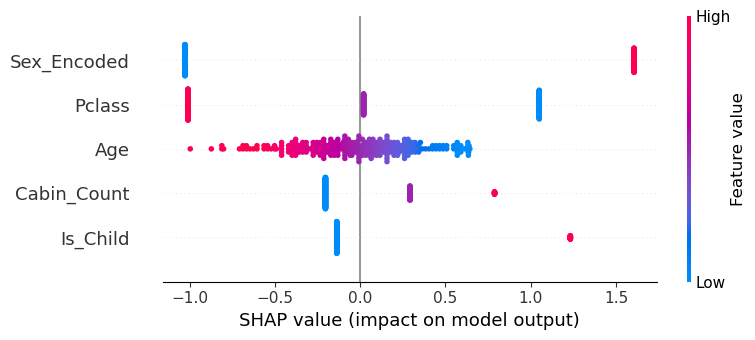

In [ ]:
model_params = {
    'class_weight': 'balanced', 
    'penalty': 'l1',  
    'C': 0.2,     
    'max_iter': 1000, 
    'solver': 'liblinear'
}

clf = LogisticRegression(**model_params, random_state=42)

with mlflow.start_run():
    mlflow.set_tag("dataset", "X_train")

    mlflow.log_params(model_params)
    mlflow.log_param("model_type", "Logistic Regression")

    print(f"\nEvaluating model with training set of {len(X_train_dedup)} samples:")
    print(f"Features used:")
    for i, feat in enumerate(X_train_dedup.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    # Fit a StandardScaler and use it to standardize all features
    scaler = StandardScaler()
    X_train_dedup_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_dedup), 
        columns=X_train_dedup.columns,
        index=X_train_dedup.index
    )

    clf.fit(X_train_dedup_scaled, y_train_dedup)

    # Predict on training set to assess bias
    y_pred = clf.predict(X_train_dedup_scaled)

    training_acc  = accuracy_score(y_train_dedup, y_pred)
    training_prec = precision_score(y_train_dedup, y_pred, average='macro')
    training_rec  = recall_score(y_train_dedup, y_pred, average='macro')
    training_f1   = f1_score(y_train_dedup, y_pred, average='macro')

    mlflow.log_metrics({
        "accuracy": training_acc,
        "precision": training_prec,
        "recall": training_rec,
        "f1": training_f1
    })

    print("\nTraining Set Scores:")
    print("Training accuracy :", training_acc)
    print("Training precision:", training_prec)
    print("Training recall   :", training_rec)
    print("Training F1-score :", training_f1)

    coef_df = pd.DataFrame(clf.coef_.T, index=X_train_dedup.columns, columns=['Coefficient'])
    print("\nModel Coefficients:")
    print(coef_df.sort_values(by='Coefficient', ascending=False))
    print()

    print_diagnostics(y_train_dedup, y_pred)

    # Print SHAP summary plot
    explainer = shap.LinearExplainer(clf, X_train_dedup_scaled)
    shap_values = explainer.shap_values(X_train_dedup_scaled)
    shap.summary_plot(shap_values, X_train_dedup_scaled, plot_type="dot", show=False)

### Dev Set Evaluation

In [ ]:
X_dev = engineer_features(X_dev)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    1
Name: count, dtype: int64


In [ ]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "X_dev")

    mlflow.log_params(model_params)
    mlflow.log_param("model_type", "Logistic Regression")

    print(f"\nEvaluating model with train-dev set of {len(X_dev)} samples:")
    print(f"Features used:")
    for i, feat in enumerate(X_dev[selected_features].columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    # Standardize all features with the same scaler used for training
    X_dev[selected_features] = scaler.transform(X_dev[selected_features])

    y_pred = clf.predict(X_dev[selected_features])

    dev_acc  = accuracy_score(y_dev, y_pred)
    dev_prec = precision_score(y_dev, y_pred, average='macro')
    dev_rec  = recall_score(y_dev, y_pred, average='macro')
    dev_f1   = f1_score(y_dev, y_pred, average='macro')

    mlflow.log_metrics({
        "accuracy": dev_acc,
        "precision": dev_prec,
        "recall": dev_rec,
        "f1": dev_f1
    })

    print("\nDev Set Scores:")
    print("Dev accuracy :", dev_acc)
    print("Dev precision:", dev_prec)
    print("Dev recall   :", dev_rec)
    print("Dev F1:", dev_f1)
    print()
    print_diagnostics(y_dev, y_pred)


Evaluating model with train-dev set of 178 samples:
Features used:
* Pclass
* Age
* Sex_Encoded
* Cabin_Count
* Is_Child

Dev Set Scores:
Dev accuracy : 0.8033707865168539
Dev precision: 0.7915835660151576
Dev recall   : 0.7931818181818182
Dev F1: 0.792354097923541


DIAGNOSTIC ANALYSIS
Actual class distribution:
Not Survived (0): 110 (61.8%)
Survived (1): 68 (38.2%)

Predicted class distribution:
Not Survived (0): 109 (61.2%)
Survived (1): 69 (38.8%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.84      0.84      0.84       110
    Survived       0.74      0.75      0.74        68

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178


Confusion Matrix:
[[92 18]
 [17 51]]
🏃 View run receptive-foal-305 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/57495a60e75f464ea812bf6a2be

### Cross-Validation Evaluation

In [ ]:
X_train_full = pd.concat([X_train[selected_features], X_dev[selected_features]], ignore_index=True)
y_train_full = pd.concat([y_train, y_dev], ignore_index=True)
X_train_full, y_train_full = remove_duplicates_and_trim(X_train_full, selected_features, y_train_full)

Before Deduplication and Trim: (711, 5), (711,)
After Deduplication and Trim: (369, 5), (369,)


In [ ]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "X_train_full")

    mlflow.log_params(model_params)
    mlflow.log_param("model_type", "Logistic Regression")

    print(f"\nEvaluating model with validation set of {len(X_train_full)} samples:")
    print(f"Features used:")
    for i, feat in enumerate(X_train_full.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision_macro', 
        'recall': 'recall_macro',
        'f1': 'f1_macro'
    }

    # Create pipeline to standardize features and then fit the model
    # Create new scaler here so cross_validate can refit it on each k-1 fold training set
    pipeline = make_pipeline(
        StandardScaler(),
        clf
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(pipeline, X_train_full, y_train_full, cv=cv, scoring=scoring)

    for metric_name, scores in cv_results.items():
        if metric_name.startswith('test_'):
            mean_score = scores.mean()
            std_score = scores.std()
            print(f"CV {metric_name[5:]}: {mean_score:.4f} ± {std_score:.4f}")
            
            mlflow.log_metric(f"{metric_name[5:]}", mean_score)
            mlflow.log_metric(f"{metric_name[5:]}_std", std_score)
    
    cv_acc_mean = cv_results['test_accuracy'].mean()
    cv_acc_std = cv_results['test_accuracy'].std()
    cv_prec_mean = cv_results['test_precision'].mean()
    cv_prec_std = cv_results['test_precision'].std()
    cv_rec_mean = cv_results['test_recall'].mean()
    cv_rec_std = cv_results['test_recall'].std()
    cv_f1_mean = cv_results['test_f1'].mean()
    cv_f1_std = cv_results['test_f1'].std()

    print("\nCross Validation Scores:")
    print("Cross Validation accuracy:", cv_acc_mean)
    print("Cross Validation accuracy (std):", cv_acc_std)
    print("Cross Validation precision:", cv_prec_mean)
    print("Cross Validation precision (std):", cv_prec_std)
    print("Cross Validation recall:", cv_rec_mean)
    print("Cross Validation recall (std):", cv_rec_std)
    print("Cross Validation F1-score:", cv_f1_mean)
    print("Cross Validation F1-score (std):", cv_f1_std)


Evaluating model with validation set of 369 samples:
Features used:
* Pclass
* Age
* Sex_Encoded
* Cabin_Count
* Is_Child
CV accuracy: 0.7779 ± 0.0435
CV precision: 0.7817 ± 0.0378
CV recall: 0.7817 ± 0.0386
CV f1: 0.7765 ± 0.0429

Cross Validation Scores:
Cross Validation accuracy: 0.7779340984820438
Cross Validation accuracy (std): 0.04348540397330909
Cross Validation precision: 0.7816789593605875
Cross Validation precision (std): 0.037788435281461336
Cross Validation recall: 0.7816693722943723
Cross Validation recall (std): 0.03861332031160841
Cross Validation F1-score: 0.7765445553645056
Cross Validation F1-score (std): 0.04287561925974754
🏃 View run legendary-lynx-458 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/c2ea0cbfae7c404981f7972343d02111
🧪 View experiment at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3


### Training Holdout Set Evaluation

In [ ]:
X_train_holdout = engineer_features(X_train_holdout)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    1
Name: count, dtype: int64


In [ ]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "x_train_holdout")

    print(f"\nEvaluating model with {len(X_train_holdout[selected_features].columns)} features:")
    for i, feat in enumerate(X_train_holdout[selected_features].columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    # Reuse the same scaler used for training to standardize features
    X_train_holdout[selected_features] = scaler.transform(X_train_holdout[selected_features])

    # Predict on the Train Holdout set
    y_pred = clf.predict(X_train_holdout[selected_features])

    holdout_acc  = accuracy_score(y_train_holdout, y_pred)
    holdout_prec = precision_score(y_train_holdout, y_pred, average='macro')
    holdout_rec  = recall_score(y_train_holdout, y_pred, average='macro')
    holdout_f1   = f1_score(y_train_holdout, y_pred, average='macro')

    print("\nTrain Holdout Set Scores:")
    print("Train Holdout Set accuracy :", holdout_acc)
    print("Train Holdout Set precision:", holdout_prec)
    print("Train Holdout Set recall   :", holdout_rec)
    print("Train Holdout Set F1:", holdout_f1)
    print()
    print_diagnostics(y_train_holdout, y_pred)

    mlflow.log_metrics({
        "accuracy": holdout_acc,
        "precision": holdout_prec,
        "recall": holdout_rec,
        "f1": holdout_f1
    })

# Output SHAP Summary Plot
# Ensure all data is proper numeric type
# X_train_shap = X_train[numerical_features_to_test].astype(np.float64)
# X_val_shap = X_val[numerical_features_to_test].astype(np.float64)
# explainer   = shap.LinearExplainer(clf, X_train_shap)
# shap_values = explainer.shap_values(X_val_shap)
# shap.summary_plot(
#     shap_values, X_val_shap, plot_type='dot', show=True,
#     max_display=100
# )


Evaluating model with 5 features:
* Pclass
* Age
* Sex_Encoded
* Cabin_Count
* Is_Child

Train Holdout Set Scores:
Train Holdout Set accuracy : 0.7988826815642458
Train Holdout Set precision: 0.7874934793948878
Train Holdout Set recall   : 0.7904479578392622
Train Holdout Set F1: 0.788859764089122


DIAGNOSTIC ANALYSIS
Actual class distribution:
Not Survived (0): 110 (61.5%)
Survived (1): 69 (38.5%)

Predicted class distribution:
Not Survived (0): 108 (60.3%)
Survived (1): 71 (39.7%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.84      0.83      0.83       110
    Survived       0.73      0.75      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[91 19]
 [17 52]]
🏃 View run traveling-bird-906 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3

### Evaluation Summary

In [ ]:
# Create table summarizing evaluation scores across training, dev, cv, and holdout sets
def create_evaluation_summary_table():
    """
    Creates a DataFrame summarizing evaluation scores across training, dev, cv, and holdout sets.
    
    Returns:
    - pd.DataFrame: Summary table with evaluation scores.
    """
    data = {
        'Set': ['Training', 'Dev', 'Cross Validation', 'Holdout'],
        'Accuracy': [training_acc, dev_acc, cv_acc_mean, holdout_acc],
        'Precision': [training_prec, dev_prec, cv_prec_mean, holdout_prec],
        'Recall': [training_rec, dev_rec, cv_rec_mean, holdout_rec],
        'F1 Score': [training_f1, dev_f1, cv_f1_mean, holdout_f1]
    }
    
    summary_df = pd.DataFrame(data)
    return summary_df

summary_table = create_evaluation_summary_table()
print("\nEvaluation Summary Table:")
print(summary_table)


Evaluation Summary Table:
                Set  Accuracy  Precision    Recall  F1 Score
0          Training  0.829365   0.829827  0.833929  0.828910
1               Dev  0.803371   0.791584  0.793182  0.792354
2  Cross Validation  0.777934   0.781679  0.781669  0.776545
3           Holdout  0.798883   0.787493  0.790448  0.788860


## Submission File Generation

In [ ]:
X_test.isnull().sum().loc[lambda x: x > 0]

Fare       1
Cabin    327
dtype: int64

In [ ]:
X_test[X_test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Ticket_Prefix,Ticket_Number,Family_Size,Is_Alone,Cabin_Count,Cabin_Number,Cabin_Side,Cabin_Missing,Age_Missing,Is_Child
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,...,,3701,1,1,0,0,Starboard,1,0,0


In [ ]:
X_test['Fare'] = X_test['Fare'].fillna(X_test.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

In [ ]:
X_test.isnull().sum().loc[lambda x: x > 0]

Cabin    327
dtype: int64

In [ ]:
X_test = engineer_features(X_test)

Non-numeric Ticket Numbers in training data:
Series([], Name: count, dtype: int64)


In [ ]:
submission = pd.DataFrame({
    'PassengerId': X_test['PassengerId'],
    'Survived': clf.predict(X_test[selected_features])
})
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
filename = f'./submission-{timestamp}.csv'
submission.to_csv(filename, index=False)

-----------

In [ ]:
import json
import re

def slugify(text):
    text = text.strip()
    text = re.sub(r'[^\w\s\-]', '', text)  # allow (), - and alphanumerics
    return re.sub(r'[\s]+', '-', text)

def extract_headings(ipynb_path):
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    toc_lines = [] # ["## Table of Contents\n"]
    for cell in nb['cells']:
        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                match = re.match(r'^(#{2,6})\s+(.*)', line)
                if match:
                    level = len(match.group(1)) - 1  # offset for nesting
                    title = match.group(2).strip()
                    anchor = slugify(title)
                    indent = '    ' * (level - 1)
                    toc_lines.append(f"{indent}1. [{title}](#{anchor})")

    return '\n'.join(toc_lines)

# Example usage:
toc = extract_headings("titanic_ml_from_disaster_abridged__paultongyoo.ipynb")
print(toc)

1. [Table of Contents](#Table-of-Contents)
1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
1. [Feature Engineering](#Feature-Engineering)
1. [Training x Test Set Distribution Comparison](#Training-x-Test-Set-Distribution-Comparison)
1. [Model Development](#Model-Development)
    1. [Training Set Evaluation](#Training-Set-Evaluation)
    1. [Dev Set Evaluation](#Dev-Set-Evaluation)
    1. [Cross-Validation Evaluation](#Cross-Validation-Evaluation)
    1. [Training Holdout Set Evaluation](#Training-Holdout-Set-Evaluation)
    1. [Evaluation Summary](#Evaluation-Summary)
1. [S